# Bates and 3/2 SV Model: Numerical Validation Demo

Validates two models in the `foureng` package against published reference values:

- **Bates (1996)**: Heston diffusion × Merton lognormal jumps. Reference prices from
  MathWorks Financial Toolbox `optByBatesNI`, `optByBatesFFT`, and `optSensByBatesNI`.
- **3/2 Stochastic Volatility** (Lewis 2000): Frozen reference surface generated by
  `pyfeng_fft`, validated against `cos_improved` and `lewis`.

Each section ends with an **assertion gate**. Benchmark CSVs are written to `benchmarks/`.

---
Instructor-requested validation demo.

| Section | What it checks | Reference | Tolerance |
|---------|---------------|-----------|----------|
| BATES-01 | NI prices, 5 strikes T=0.5 | MathWorks NI | 1e-2 |
| BATES-02 | cos_improved vs Lewis cross-check | Internal | 1e-2 |
| BATES-03 | NI surface 5×6 heatmap | MathWorks NI | 1e-2 |
| BATES-04 | COS convergence in N | Lewis high-res | — |
| BATES-05 | Implied-vol smile | Derived from prices | — |
| BATES-06 | FRFT tuned surface | Internal cos_improved | 1e-3 |
| BATES-07 | Delta vs MathWorks | MathWorks NI | 5e-3 |
| SV32-01 | pyfeng_fft & cos_improved vs frozen | Frozen pyfeng_fft | 5e-4 / 1e-3 |
| SV32-02 | cos_improved vs pyfeng_fft 7×4 | Frozen pyfeng_fft | 1.5e-3 |
| SV32-03 | Lewis vs pyfeng_fft T≥0.5 | Frozen pyfeng_fft | 1.5e-3 |
| SV32-04 | IV surface heatmap | — | — |
| SV32-05 | COS-improved convergence in N | pyfeng_fft | — |

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import foureng as fe
from foureng.pricers.lewis import lewis_call_prices
from foureng.pricers.cos import cos_auto_grid, cos_prices
from foureng.iv.implied_vol import BSInputs, implied_vol_newton_safeguarded as implied_vol

REPO = Path("../..")
REFS = REPO / "tests" / "refs"
BENCHMARKS = REPO / "benchmarks"
BENCHMARKS.mkdir(exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("foureng:", fe.__version__)

/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


foureng: 0.3.1


---
## Bates model
### Parameters (MathWorks convention)

MathWorks specifies jumps via a proportional mean jump `MeanJ`; the log-jump mean used
in the CF is $\mu_j = \ln(1 + \text{MeanJ}) - \frac{1}{2}\sigma_j^2$.

In [2]:
with open(REFS / "bates_mathworks_reference.json") as f:
    bates_ref = json.load(f)
with open(REFS / "bates_mathworks_ni_surface.json") as f:
    bates_surf_ref = json.load(f)
with open(REFS / "bates_mathworks_fft_frft.json") as f:
    bates_fft_ref = json.load(f)
with open(REFS / "bates_mathworks_delta.json") as f:
    bates_delta_ref = json.load(f)

BATES_PARAMS = fe.BatesParams(
    kappa=bates_ref["kappa"],
    theta=bates_ref["theta"],
    nu=bates_ref["sigma_v"],
    rho=bates_ref["rho"],
    v0=bates_ref["v0"],
    lam_j=bates_ref["jump_frequency"],
    mu_j=bates_ref["converted_log_jump_mean"],
    sigma_j=bates_ref["jump_vol"],
)
BATES_FWD = fe.ForwardSpec(
    S0=bates_ref["spot"], r=bates_ref["risk_free_rate"],
    q=bates_ref["dividend_yield"], T=bates_ref["maturity"],
)
BATES_STRIKES = np.array(bates_ref["strikes"], dtype=float)
MW_PRICES     = np.array(bates_ref["call_prices"], dtype=float)
OWN_PRICES    = np.array(bates_ref["call_prices_our_convention"], dtype=float)

print(f"S0={bates_ref['spot']}, r={bates_ref['risk_free_rate']}, "
      f"q={bates_ref['dividend_yield']}, T={bates_ref['maturity']}")
print(f"mu_j = {bates_ref['converted_log_jump_mean']:.12f}")
print("Strikes:", BATES_STRIKES)
print("MathWorks NI prices:", MW_PRICES)

S0=80.0, r=0.03, q=0.02, T=0.5
mu_j = 0.016602627296
Strikes: [76. 78. 80. 82. 84.]
MathWorks NI prices: [7.5765 6.402  5.3484 4.4173 3.6073]


### BATES-01: NI prices vs MathWorks reference (T = 0.5)

In [3]:
prices_cos = fe.price_strip("bates", "cos_improved", BATES_STRIKES, BATES_FWD, BATES_PARAMS)

phi_bates = lambda u: fe.bates_cf(u, BATES_FWD, BATES_PARAMS)
prices_lewis = lewis_call_prices(
    phi_bates, BATES_STRIKES,
    spot=BATES_FWD.S0, texp=BATES_FWD.T,
    intr=BATES_FWD.r, divr=BATES_FWD.q,
    method="trapz", u_max=200.0, n_u=8192,
)

df_01 = pd.DataFrame({
    "Strike":         BATES_STRIKES,
    "MathWorks NI":   MW_PRICES,
    "Our convention": OWN_PRICES,
    "cos_improved":   prices_cos,
    "lewis":          prices_lewis,
    "err_vs_MW":      np.abs(prices_cos - MW_PRICES),
    "err_vs_own":     np.abs(prices_cos - OWN_PRICES),
})
print(df_01.to_string(index=False, float_format="{:.6f}".format))

bates_01_cos_improved_error = float(np.abs(prices_cos - MW_PRICES).max())
print(f"\nMax |cos_improved - MathWorks| = {bates_01_cos_improved_error:.2e}")
assert bates_01_cos_improved_error <= 1e-2, (
    f"BATES-01 FAILED: {bates_01_cos_improved_error:.2e} > 1e-2")
print("BATES-01 PASSED")

   Strike  MathWorks NI  Our convention  cos_improved    lewis  err_vs_MW  err_vs_own
76.000000      7.576500        7.569345      7.569345 7.569345   0.007155    0.000000
78.000000      6.402000        6.394531      6.394531 6.394531   0.007469    0.000000
80.000000      5.348400        5.340802      5.340802 5.340802   0.007598    0.000000
82.000000      4.417300        4.409768      4.409768 4.409768   0.007532    0.000000
84.000000      3.607300        3.599948      3.599948 3.599948   0.007352    0.000000

Max |cos_improved - MathWorks| = 7.60e-03
BATES-01 PASSED


### BATES-02: cos_improved vs Lewis cross-method agreement

     Strike  cos_improved      lewis       diff
76.00000000    7.56934498 7.56934498 0.00000000
78.00000000    6.39453139 6.39453139 0.00000000
80.00000000    5.34080249 5.34080249 0.00000000
82.00000000    4.40976754 4.40976754 0.00000000
84.00000000    3.59994758 3.59994758 0.00000000


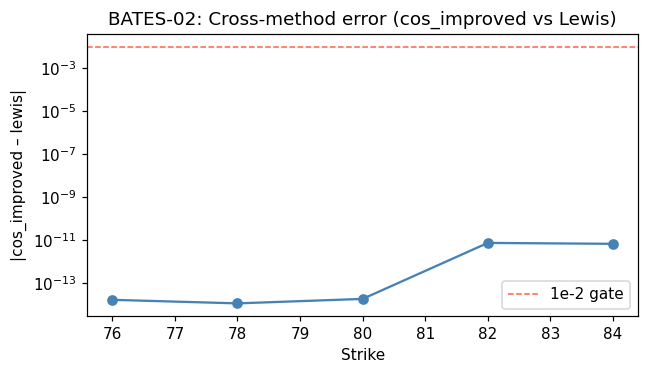

Max cross-method error = 7.54e-12
BATES-02 PASSED


In [4]:
err_cross = np.abs(prices_cos - prices_lewis)
print(pd.DataFrame({"Strike": BATES_STRIKES,
                    "cos_improved": prices_cos,
                    "lewis": prices_lewis,
                    "diff": err_cross})
      .to_string(index=False, float_format="{:.8f}".format))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(BATES_STRIKES, err_cross, "o-", color="steelblue")
ax.axhline(1e-2, ls="--", color="tomato", lw=1, label="1e-2 gate")
ax.set_xlabel("Strike"); ax.set_ylabel("|cos_improved – lewis|")
ax.set_title("BATES-02: Cross-method error (cos_improved vs Lewis)")
ax.legend(); plt.tight_layout(); plt.show()

bates_02_cos_improved_max_error = float(err_cross.max())
print(f"Max cross-method error = {bates_02_cos_improved_max_error:.2e}")
assert bates_02_cos_improved_max_error <= 1e-2, (
    f"BATES-02 FAILED: {bates_02_cos_improved_max_error:.2e} > 1e-2")
print("BATES-02 PASSED")

### BATES-03: NI surface 5×6 heatmap

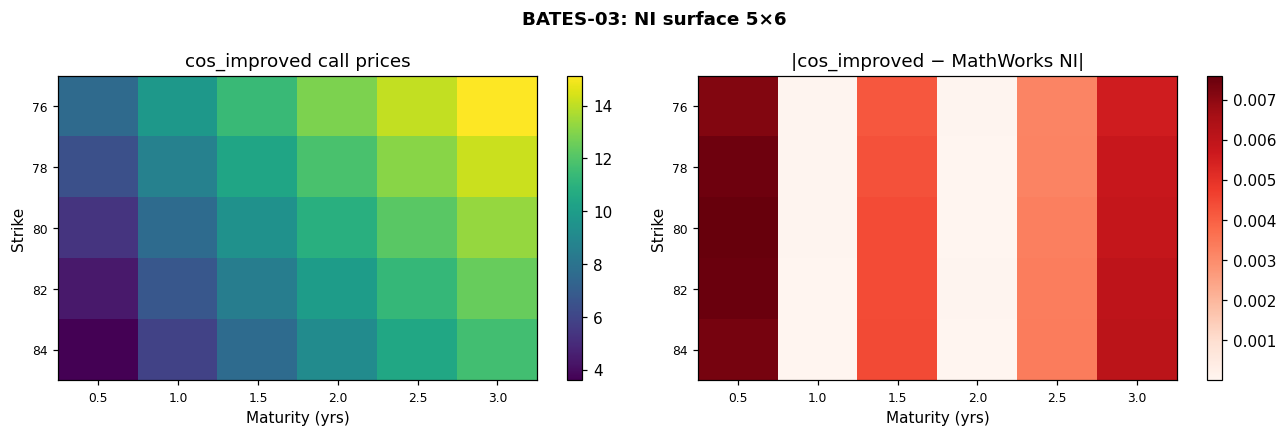

Max surface error = 7.5975e-03
BATES-03 PASSED — benchmarks/bates_ni_surface_demo.csv


In [5]:
surf_K  = np.array(bates_surf_ref["strikes"], dtype=float)
surf_T  = np.array(bates_surf_ref["maturities_years"], dtype=float)
surf_mw = np.array(bates_surf_ref["call_price_surface"], dtype=float)

surf_cos = np.empty_like(surf_mw)
for j, T in enumerate(surf_T):
    fwd_j = fe.ForwardSpec(S0=bates_surf_ref["spot"],
                           r=bates_surf_ref["risk_free_rate"],
                           q=bates_surf_ref["dividend_yield"], T=float(T))
    surf_cos[:, j] = fe.price_strip("bates", "cos_improved", surf_K, fwd_j, BATES_PARAMS)

surf_err = np.abs(surf_cos - surf_mw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title, cmap in zip(
    axes,
    [surf_cos, surf_err],
    ["cos_improved call prices", "|cos_improved − MathWorks NI|"],
    ["viridis", "Reds"],
):
    im = ax.imshow(data, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(surf_T)))
    ax.set_xticklabels([f"{T:.1f}" for T in surf_T], fontsize=8)
    ax.set_yticks(range(len(surf_K)))
    ax.set_yticklabels([f"{K:.0f}" for K in surf_K], fontsize=8)
    ax.set_xlabel("Maturity (yrs)"); ax.set_ylabel("Strike"); ax.set_title(title)
    plt.colorbar(im, ax=ax)
plt.suptitle("BATES-03: NI surface 5×6", fontweight="bold")
plt.tight_layout(); plt.show()

bates_03_surface_max_error = float(surf_err.max())
print(f"Max surface error = {bates_03_surface_max_error:.4e}")
assert bates_03_surface_max_error <= 1e-2, (
    f"BATES-03 FAILED: {bates_03_surface_max_error:.4e} > 1e-2")

rows = [{"strike": K, "maturity": T, "mw_ni": surf_mw[i, j],
         "cos_improved": surf_cos[i, j], "abs_err": surf_err[i, j]}
        for i, K in enumerate(surf_K) for j, T in enumerate(surf_T)]
pd.DataFrame(rows).to_csv(BENCHMARKS / "bates_ni_surface_demo.csv", index=False)
print("BATES-03 PASSED — benchmarks/manual_runs/bates_ni_surface_demo.csv")

### BATES-04: COS-improved convergence in N (ATM)

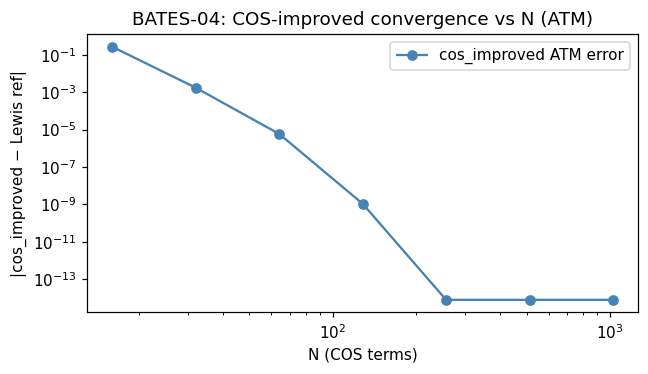

ATM Lewis ref = 5.34080249
  N=   16  error=2.663e-01
  N=   32  error=1.729e-03
  N=   64  error=5.882e-06
  N=  128  error=1.096e-09
  N=  256  error=7.994e-15
  N=  512  error=7.994e-15
  N= 1024  error=7.994e-15


In [6]:
atm_k = np.array([BATES_FWD.S0])

# High-resolution Lewis as reference
ref_atm = float(lewis_call_prices(
    phi_bates, atm_k,
    spot=BATES_FWD.S0, texp=BATES_FWD.T,
    intr=BATES_FWD.r, divr=BATES_FWD.q,
    method="trapz", u_max=500.0, n_u=65536,
)[0])

# Get a baseline grid (a, b) from the default cumulants; vary N
cums_bates = fe.bates_cumulants(BATES_FWD, BATES_PARAMS)
base_grid  = cos_auto_grid(cums_bates, N=1024, L=12.0)
a, b = base_grid.a, base_grid.b

n_values = [16, 32, 64, 128, 256, 512, 1024]
errors = []
for N in n_values:
    grid_n = fe.COSGrid(N=N, a=a, b=b)
    # cos_improved with a COSGrid uses cos_prices directly
    p = float(fe.price_strip("bates", "cos_improved", atm_k,
                             BATES_FWD, BATES_PARAMS, grid=grid_n)[0])
    errors.append(abs(p - ref_atm))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.loglog(n_values, errors, "o-", color="steelblue", label="cos_improved ATM error")
ax.set_xlabel("N (COS terms)"); ax.set_ylabel("|cos_improved − Lewis ref|")
ax.set_title("BATES-04: COS-improved convergence vs N (ATM)")
ax.legend(); plt.tight_layout(); plt.show()

print(f"ATM Lewis ref = {ref_atm:.8f}")
for n, e in zip(n_values, errors):
    print(f"  N={n:5d}  error={e:.3e}")

### BATES-05: Implied-vol smile

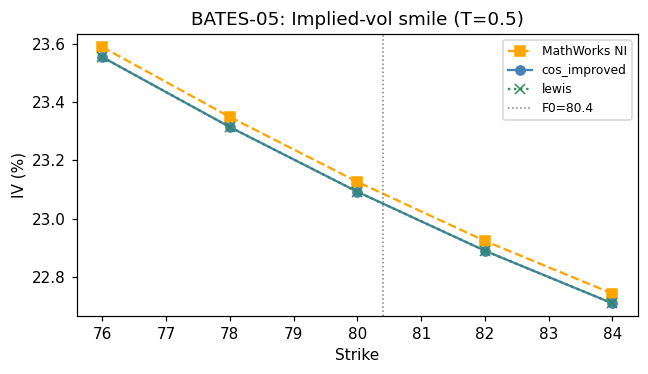

IV (cos_improved, %): [23.56 23.31 23.09 22.89 22.71]


In [7]:
def to_iv(prices, strikes, fwd):
    result = []
    for p, K in zip(prices, strikes):
        inp = BSInputs(F0=fwd.F0, K=float(K), T=fwd.T, r=fwd.r, q=fwd.q)
        try:
            result.append(implied_vol(float(p), inp))
        except Exception:
            result.append(float("nan"))
    return np.array(result)

iv_mw    = to_iv(MW_PRICES, BATES_STRIKES, BATES_FWD)
iv_cos   = to_iv(prices_cos, BATES_STRIKES, BATES_FWD)
iv_lewis = to_iv(prices_lewis, BATES_STRIKES, BATES_FWD)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(BATES_STRIKES, iv_mw * 100,    "s--", color="orange",    label="MathWorks NI")
ax.plot(BATES_STRIKES, iv_cos * 100,   "o-",  color="steelblue", label="cos_improved")
ax.plot(BATES_STRIKES, iv_lewis * 100, "x:",  color="seagreen",  label="lewis")
ax.axvline(BATES_FWD.F0, color="gray", ls=":", lw=1, label=f"F0={BATES_FWD.F0:.1f}")
ax.set_xlabel("Strike"); ax.set_ylabel("IV (%)")
ax.set_title("BATES-05: Implied-vol smile (T=0.5)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("IV (cos_improved, %):", np.round(iv_cos * 100, 2))

### BATES-06: FRFT tuned surface vs internal cos_improved reference

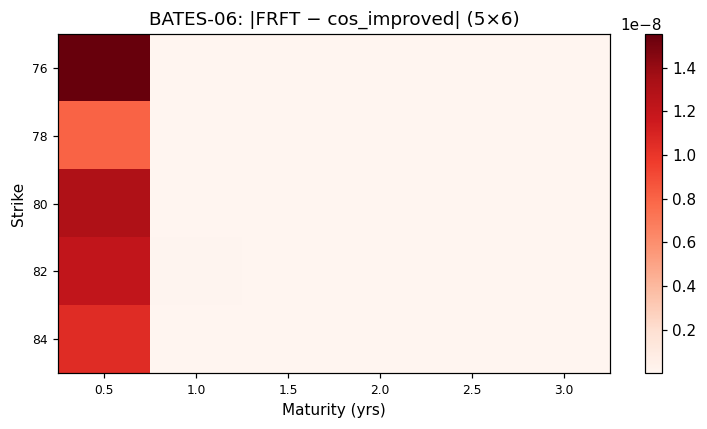

Max |FRFT − cos_improved| = 1.5529e-08
BATES-06 PASSED


In [8]:
fs       = bates_fft_ref["tuned_fft_surface"]
frft_K   = np.array(fs["strikes"], dtype=float)
frft_T   = np.array(fs["maturities_years"], dtype=float)

# Internal cos_improved as reference (avoids MathWorks 4-decimal truncation)
frft_ref = np.empty((len(frft_K), len(frft_T)))
for j, T in enumerate(frft_T):
    fwd_j = fe.ForwardSpec(S0=bates_fft_ref["spot"],
                           r=bates_fft_ref["risk_free_rate"],
                           q=bates_fft_ref["dividend_yield"], T=float(T))
    frft_ref[:, j] = fe.price_strip("bates", "cos_improved", frft_K, fwd_j, BATES_PARAMS)

# FRFT surface
grid = fe.FRFTGrid(N=fs["num_fft"], eta=fs["characteristic_function_step"],
                   lam=fs["log_strike_step"], alpha=1.5)
frft_got = np.empty_like(frft_ref)
for j, T in enumerate(frft_T):
    fwd_j = fe.ForwardSpec(S0=bates_fft_ref["spot"],
                           r=bates_fft_ref["risk_free_rate"],
                           q=bates_fft_ref["dividend_yield"], T=float(T))
    frft_got[:, j] = fe.price_strip("bates", "frft", frft_K, fwd_j, BATES_PARAMS, grid=grid)

frft_err = np.abs(frft_got - frft_ref)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(frft_err, aspect="auto", cmap="Reds")
ax.set_xticks(range(len(frft_T)))
ax.set_xticklabels([f"{T:.1f}" for T in frft_T], fontsize=8)
ax.set_yticks(range(len(frft_K)))
ax.set_yticklabels([f"{K:.0f}" for K in frft_K], fontsize=8)
ax.set_xlabel("Maturity (yrs)"); ax.set_ylabel("Strike")
ax.set_title("BATES-06: |FRFT − cos_improved| (5×6)")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

bates_06_frft_max_error = float(frft_err.max())
print(f"Max |FRFT − cos_improved| = {bates_06_frft_max_error:.4e}")
assert bates_06_frft_max_error <= 1e-3, (
    f"BATES-06 FAILED: {bates_06_frft_max_error:.4e} > 1e-3")
print("BATES-06 PASSED")

### BATES-07: Delta vs MathWorks optSensByBatesNI

   Strike  MW delta  FD delta      err
76.000000  0.680700  0.680801 0.000101
78.000000  0.623400  0.623391 0.000009
80.000000  0.563000  0.562956 0.000044
82.000000  0.501100  0.500956 0.000144
84.000000  0.439200  0.438998 0.000202


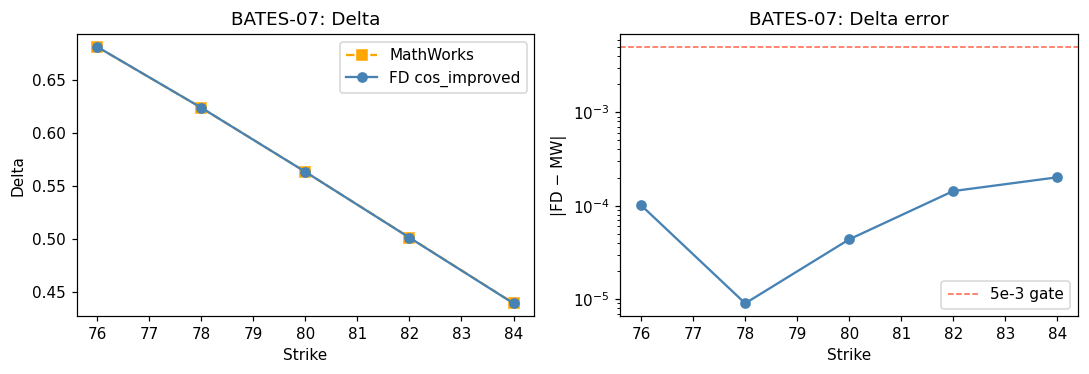

Max |FD − MW| = 2.0159e-04
BATES-07 PASSED
Saved benchmarks/bates_sv32_demo_bates_results.csv


In [9]:
delta_K  = np.array(bates_delta_ref["strikes"], dtype=float)
delta_mw = np.array(bates_delta_ref["delta"], dtype=float)

S0 = bates_delta_ref["spot"]
dS = 1e-3 * S0

def bates_strip(s0):
    fwd = fe.ForwardSpec(S0=s0, r=bates_delta_ref["risk_free_rate"],
                         q=bates_delta_ref["dividend_yield"],
                         T=bates_delta_ref["maturity"])
    return fe.price_strip("bates", "cos_improved", delta_K, fwd, BATES_PARAMS)

delta_fd  = (bates_strip(S0 + dS) - bates_strip(S0 - dS)) / (2.0 * dS)
delta_err = np.abs(delta_fd - delta_mw)

print(pd.DataFrame({"Strike": delta_K, "MW delta": delta_mw,
                    "FD delta": delta_fd, "err": delta_err})
      .to_string(index=False, float_format="{:.6f}".format))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(delta_K, delta_mw, "s--", color="orange",    label="MathWorks")
axes[0].plot(delta_K, delta_fd, "o-",  color="steelblue", label="FD cos_improved")
axes[0].set_xlabel("Strike"); axes[0].set_ylabel("Delta")
axes[0].set_title("BATES-07: Delta"); axes[0].legend()
axes[1].semilogy(delta_K, delta_err, "o-", color="steelblue")
axes[1].axhline(5e-3, ls="--", color="tomato", lw=1, label="5e-3 gate")
axes[1].set_xlabel("Strike"); axes[1].set_ylabel("|FD − MW|")
axes[1].set_title("BATES-07: Delta error"); axes[1].legend()
plt.tight_layout(); plt.show()

bates_07_delta_max_error = float(delta_err.max())
print(f"Max |FD − MW| = {bates_07_delta_max_error:.4e}")
assert bates_07_delta_max_error <= 5e-3, (
    f"BATES-07 FAILED: {bates_07_delta_max_error:.4e} > 5e-3")
print("BATES-07 PASSED")

# Save Bates benchmark
pd.DataFrame({
    "strike": BATES_STRIKES,
    "mw_ni_price": MW_PRICES,
    "cos_improved_price": prices_cos,
    "lewis_price": prices_lewis,
    "iv_mw": iv_mw,
    "iv_cos_improved": iv_cos,
    "delta_mw": delta_mw,
    "delta_fd_cos": delta_fd,
}).to_csv(BENCHMARKS / "bates_sv32_demo_bates_results.csv", index=False)
print("Saved benchmarks/manual_runs/bates_sv32_demo_bates_results.csv")

---
## 3/2 Stochastic Volatility (Sv32) model

Stable parameter set (`v0=0.06, nu=3.2`) from the `Sv32Params` docstring.
The Baldeaux-Badran original params cause instability at short maturities.

In [10]:
try:
    import pyfeng
    HAS_PYFENG = True
    print(f"pyfeng {getattr(pyfeng, '__version__', 'unknown')} available")
except ImportError:
    HAS_PYFENG = False
    print("pyfeng not installed — SV32 sections skipped")

with open(REFS / "sv32_pyfeng_surface_reference.json") as f:
    sv32_ref = json.load(f)

SV32_PARAMS = fe.Sv32Params(
    v0=sv32_ref["v0"], kappa=sv32_ref["kappa"],
    theta=sv32_ref["theta"], nu=sv32_ref["nu"], rho=sv32_ref["rho"],
)
SV32_K    = np.array(sv32_ref["strikes"], dtype=float)
SV32_T    = np.array(sv32_ref["maturities_years"], dtype=float)
SV32_SURF = np.array(sv32_ref["call_price_surface"], dtype=float)

print(f"v0={sv32_ref['v0']}, kappa={sv32_ref['kappa']}, theta={sv32_ref['theta']}, "
      f"nu={sv32_ref['nu']}, rho={sv32_ref['rho']}")
print(f"Spot={sv32_ref['spot']}, r={sv32_ref['risk_free_rate']}")
print("Strikes:", SV32_K)
print("Maturities:", np.round(SV32_T, 3))

pyfeng unknown available
v0=0.06, kappa=20.48, theta=0.218, nu=3.2, rho=-0.99
Spot=100.0, r=0.0
Strikes: [ 80.  90.  95. 100. 105. 110. 120.]
Maturities: [0.083 0.25  0.5   1.   ]


### SV32-01: pyfeng_fft and cos_improved vs frozen surface

In [11]:
if not HAS_PYFENG:
    print("Skipping SV32-01")
else:
    def sv32_surface(method):
        out = np.empty_like(SV32_SURF)
        for j, T in enumerate(SV32_T):
            fwd_j = fe.ForwardSpec(S0=sv32_ref["spot"],
                                   r=sv32_ref["risk_free_rate"],
                                   q=sv32_ref["dividend_yield"], T=float(T))
            if method == "lewis":
                phi = lambda u, _f=fwd_j: fe.sv32_cf(u, _f, SV32_PARAMS)
                out[:, j] = lewis_call_prices(
                    phi, SV32_K, spot=fwd_j.S0, texp=fwd_j.T,
                    intr=fwd_j.r, divr=fwd_j.q,
                    method="trapz", u_max=300.0, n_u=32768,
                )
            else:
                out[:, j] = fe.price_strip("sv32", method, SV32_K, fwd_j, SV32_PARAMS)
        return out

    surf_py   = sv32_surface("pyfeng_fft")
    surf_cos  = sv32_surface("cos_improved")
    err_py    = np.abs(surf_py  - SV32_SURF)
    err_ci    = np.abs(surf_cos - SV32_SURF)

    atm_i = list(SV32_K).index(100.0)
    t1_i  = list(SV32_T).index(1.0)
    print(f"ATM (K=100) T=1.0:  frozen={SV32_SURF[atm_i,t1_i]:.6f}  "
          f"pyfeng={surf_py[atm_i,t1_i]:.6f}  cos_improved={surf_cos[atm_i,t1_i]:.6f}")

    sv32_01_pyfeng_max_error       = float(err_py.max())
    sv32_01_cos_improved_max_error = float(err_ci.max())
    print(f"Max |pyfeng_fft − frozen|   = {sv32_01_pyfeng_max_error:.2e}")
    print(f"Max |cos_improved − frozen| = {sv32_01_cos_improved_max_error:.2e}")

    assert sv32_01_pyfeng_max_error       <= 5e-4, f"SV32-01 pyfeng FAILED"
    assert sv32_01_cos_improved_max_error <= 1e-3, f"SV32-01 cos_improved FAILED"
    print("SV32-01 PASSED")

ATM (K=100) T=1.0:  frozen=14.115355  pyfeng=14.115355  cos_improved=14.115355
Max |pyfeng_fft − frozen|   = 2.47e-04
Max |cos_improved − frozen| = 3.03e-09
SV32-01 PASSED


### SV32-02: cos_improved vs pyfeng_fft surface 7×4 heatmap

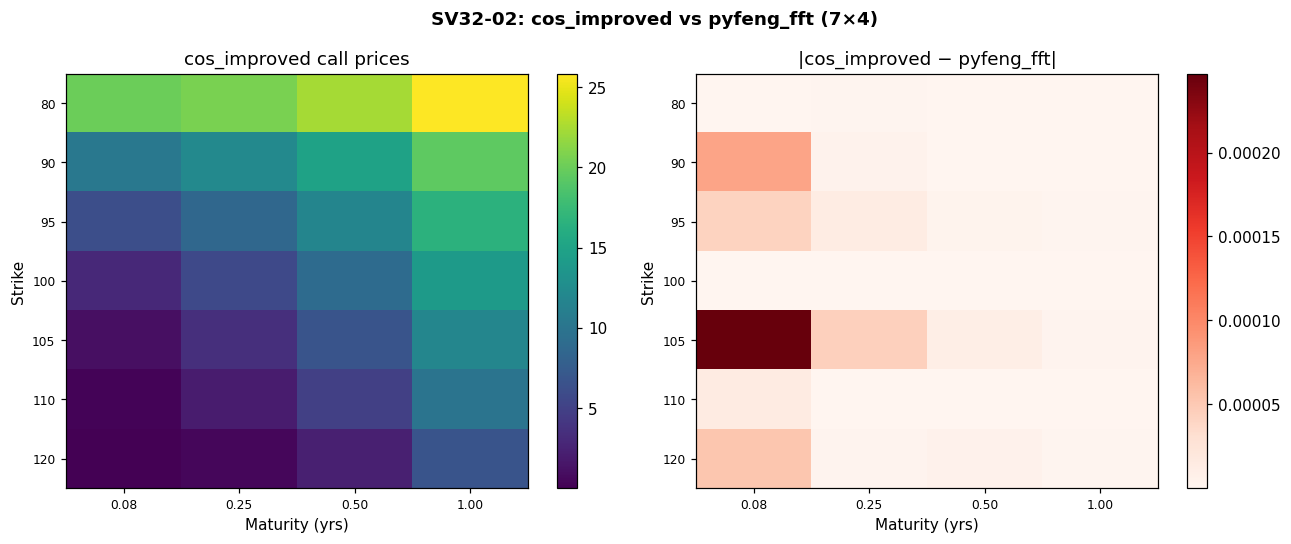

Max |cos_improved − pyfeng_fft| = 2.4700e-04
SV32-02 PASSED
Saved benchmarks/sv32_pyfeng_surface_demo.csv


In [12]:
if not HAS_PYFENG:
    print("Skipping SV32-02")
else:
    err_02 = np.abs(surf_cos - surf_py)
    mat_lb = [f"{T:.2f}" for T in SV32_T]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, data, title, cmap in zip(
        axes,
        [surf_cos, err_02],
        ["cos_improved call prices", "|cos_improved − pyfeng_fft|"],
        ["viridis", "Reds"],
    ):
        im = ax.imshow(data, aspect="auto", cmap=cmap)
        ax.set_xticks(range(len(SV32_T))); ax.set_xticklabels(mat_lb, fontsize=8)
        ax.set_yticks(range(len(SV32_K)))
        ax.set_yticklabels([f"{K:.0f}" for K in SV32_K], fontsize=8)
        ax.set_xlabel("Maturity (yrs)"); ax.set_ylabel("Strike"); ax.set_title(title)
        plt.colorbar(im, ax=ax)
    plt.suptitle("SV32-02: cos_improved vs pyfeng_fft (7×4)", fontweight="bold")
    plt.tight_layout(); plt.show()

    sv32_02_cos_vs_pyfeng_surface_error = float(err_02.max())
    print(f"Max |cos_improved − pyfeng_fft| = {sv32_02_cos_vs_pyfeng_surface_error:.4e}")
    assert sv32_02_cos_vs_pyfeng_surface_error <= 1.5e-3, (
        f"SV32-02 FAILED: {sv32_02_cos_vs_pyfeng_surface_error:.4e} > 1.5e-3")
    print("SV32-02 PASSED")

    rows = [{"strike": K, "maturity": T, "pyfeng_fft": surf_py[i, j],
             "cos_improved": surf_cos[i, j], "abs_err": err_02[i, j]}
            for i, K in enumerate(SV32_K) for j, T in enumerate(SV32_T)]
    pd.DataFrame(rows).to_csv(BENCHMARKS / "sv32_pyfeng_surface_demo.csv", index=False)
    print("Saved benchmarks/manual_runs/sv32_pyfeng_surface_demo.csv")

### SV32-03: Lewis vs pyfeng_fft for T ≥ 0.5

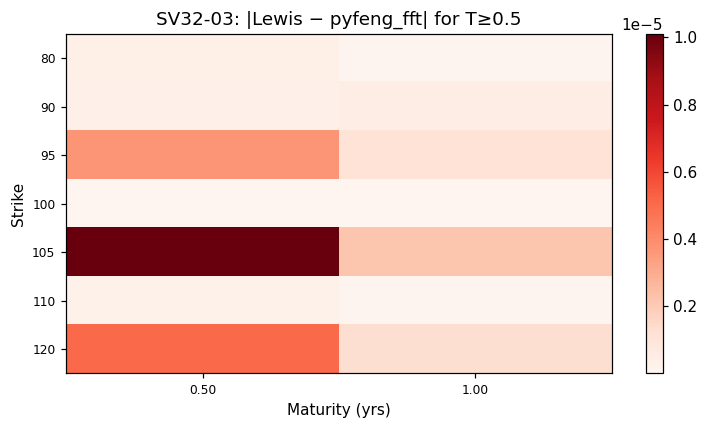

Max |Lewis − pyfeng_fft| (T≥0.5) = 1.0097e-05
SV32-03 PASSED


In [13]:
if not HAS_PYFENG:
    print("Skipping SV32-03")
else:
    long_mask   = SV32_T >= 0.5
    long_T      = SV32_T[long_mask]
    py_long     = surf_py[:, long_mask]
    surf_lewis  = np.empty((len(SV32_K), long_mask.sum()))

    for j, T in enumerate(long_T):
        fwd_j = fe.ForwardSpec(S0=sv32_ref["spot"],
                               r=sv32_ref["risk_free_rate"],
                               q=sv32_ref["dividend_yield"], T=float(T))
        phi = lambda u, _f=fwd_j: fe.sv32_cf(u, _f, SV32_PARAMS)
        surf_lewis[:, j] = lewis_call_prices(
            phi, SV32_K, spot=fwd_j.S0, texp=fwd_j.T,
            intr=fwd_j.r, divr=fwd_j.q,
            method="trapz", u_max=300.0, n_u=32768,
        )

    err_lew = np.abs(surf_lewis - py_long)

    fig, ax = plt.subplots(figsize=(7, 4))
    im = ax.imshow(err_lew, aspect="auto", cmap="Reds")
    ax.set_xticks(range(len(long_T)))
    ax.set_xticklabels([f"{T:.2f}" for T in long_T], fontsize=8)
    ax.set_yticks(range(len(SV32_K)))
    ax.set_yticklabels([f"{K:.0f}" for K in SV32_K], fontsize=8)
    ax.set_xlabel("Maturity (yrs)"); ax.set_ylabel("Strike")
    ax.set_title("SV32-03: |Lewis − pyfeng_fft| for T≥0.5")
    plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

    lewis_max_err = float(err_lew.max())
    print(f"Max |Lewis − pyfeng_fft| (T≥0.5) = {lewis_max_err:.4e}")
    assert lewis_max_err <= 1.5e-3, (
        f"SV32-03 FAILED: {lewis_max_err:.4e} > 1.5e-3")
    print("SV32-03 PASSED")

### SV32-04: Implied-vol surface heatmap (cos_improved)

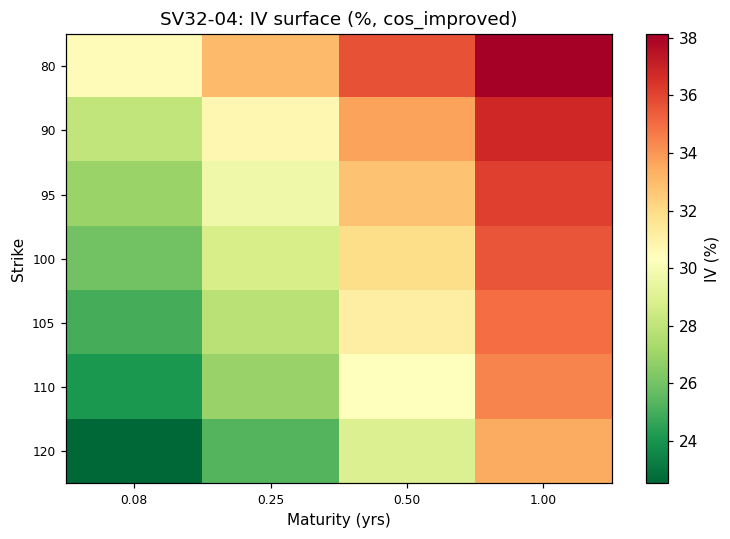

       T=0.08  T=0.25  T=0.50  T=1.00
K=80    30.53   33.04   35.67   38.12
K=90    28.06   30.72   33.71   36.78
K=95    26.97   29.68   32.82   36.16
K=100   25.95   28.70   31.96   35.57
K=105   25.01   27.78   31.16   35.00
K=110   24.13   26.91   30.39   34.46
K=120   22.54   25.33   28.96   33.43


In [14]:
if not HAS_PYFENG:
    print("Skipping SV32-04")
else:
    iv_surf = np.full_like(surf_cos, np.nan)
    for j, T in enumerate(SV32_T):
        fwd_j = fe.ForwardSpec(S0=sv32_ref["spot"],
                               r=sv32_ref["risk_free_rate"],
                               q=sv32_ref["dividend_yield"], T=float(T))
        for i, K in enumerate(SV32_K):
            inp = BSInputs(F0=fwd_j.F0, K=float(K), T=T, r=fwd_j.r, q=fwd_j.q)
            try:
                iv_surf[i, j] = implied_vol(surf_cos[i, j], inp)
            except Exception:
                pass

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(iv_surf * 100, aspect="auto", cmap="RdYlGn_r")
    ax.set_xticks(range(len(SV32_T)))
    ax.set_xticklabels([f"{T:.2f}" for T in SV32_T], fontsize=8)
    ax.set_yticks(range(len(SV32_K)))
    ax.set_yticklabels([f"{K:.0f}" for K in SV32_K], fontsize=8)
    ax.set_xlabel("Maturity (yrs)"); ax.set_ylabel("Strike")
    ax.set_title("SV32-04: IV surface (%, cos_improved)")
    plt.colorbar(im, ax=ax, label="IV (%)"); plt.tight_layout(); plt.show()

    print(pd.DataFrame(
        np.round(iv_surf * 100, 2),
        index=[f"K={K:.0f}" for K in SV32_K],
        columns=[f"T={T:.2f}" for T in SV32_T],
    ).to_string())

### SV32-05: COS-improved convergence vs N (ATM, T=1.0)

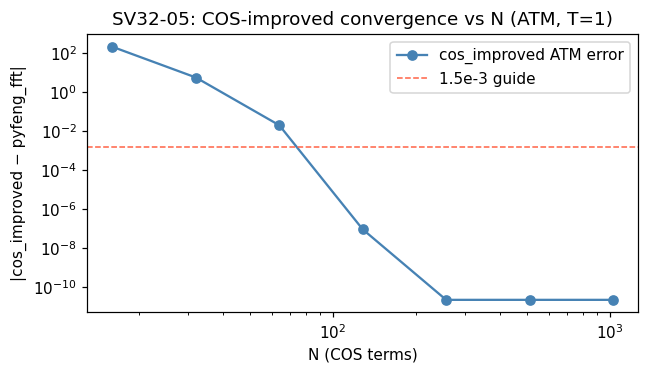

pyfeng_fft ATM ref (T=1.0) = 14.11535460
  N=   16  err=2.105e+02
  N=   32  err=5.608e+00
  N=   64  err=1.989e-02
  N=  128  err=9.090e-08
  N=  256  err=2.198e-11
  N=  512  err=2.198e-11
  N= 1024  err=2.198e-11


In [15]:
if not HAS_PYFENG:
    print("Skipping SV32-05")
else:
    fwd_t1  = fe.ForwardSpec(S0=sv32_ref["spot"],
                             r=sv32_ref["risk_free_rate"],
                             q=sv32_ref["dividend_yield"], T=1.0)
    atm_k   = np.array([sv32_ref["spot"]])
    ref_sv  = float(fe.price_strip("sv32", "pyfeng_fft", atm_k, fwd_t1, SV32_PARAMS)[0])

    # Build baseline [a,b] from cumulants; vary N
    cums_sv32 = fe.sv32_cumulants(fwd_t1, SV32_PARAMS)
    base_g    = cos_auto_grid(cums_sv32, N=1024, L=12.0)

    n_vals = [16, 32, 64, 128, 256, 512, 1024]
    sv32_errs = []
    for N in n_vals:
        g = fe.COSGrid(N=N, a=base_g.a, b=base_g.b)
        p = float(fe.price_strip("sv32", "cos_improved", atm_k,
                                 fwd_t1, SV32_PARAMS, grid=g)[0])
        sv32_errs.append(abs(p - ref_sv))

    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.loglog(n_vals, sv32_errs, "o-", color="steelblue", label="cos_improved ATM error")
    ax.axhline(1.5e-3, ls="--", color="tomato", lw=1, label="1.5e-3 guide")
    ax.set_xlabel("N (COS terms)"); ax.set_ylabel("|cos_improved − pyfeng_fft|")
    ax.set_title("SV32-05: COS-improved convergence vs N (ATM, T=1)")
    ax.legend(); plt.tight_layout(); plt.show()

    print(f"pyfeng_fft ATM ref (T=1.0) = {ref_sv:.8f}")
    for n, e in zip(n_vals, sv32_errs):
        print(f"  N={n:5d}  err={e:.3e}")

---
## Summary dashboard

In [16]:
rows = [
    ("BATES-01", "NI prices 5K T=0.5 vs MathWorks",     1e-2, bates_01_cos_improved_error),
    ("BATES-02", "cos_improved vs Lewis cross-method",   1e-2, bates_02_cos_improved_max_error),
    ("BATES-03", "NI surface 5×6 vs MathWorks",          1e-2, bates_03_surface_max_error),
    ("BATES-06", "FRFT surface vs cos_improved NI ref",  1e-3, bates_06_frft_max_error),
    ("BATES-07", "Delta vs MathWorks optSensByBatesNI",  5e-3, bates_07_delta_max_error),
]
if HAS_PYFENG:
    rows += [
        ("SV32-01a", "pyfeng_fft vs frozen surface",          5e-4,  sv32_01_pyfeng_max_error),
        ("SV32-01b", "cos_improved vs frozen surface",        1e-3,  sv32_01_cos_improved_max_error),
        ("SV32-02",  "cos_improved vs pyfeng_fft 7×4",        1.5e-3,sv32_02_cos_vs_pyfeng_surface_error),
        ("SV32-03",  "Lewis vs pyfeng_fft T≥0.5",             1.5e-3,lewis_max_err),
    ]

df_sum = pd.DataFrame(rows, columns=["section", "description", "tolerance", "max_error"])
df_sum["pass"]   = df_sum["max_error"] <= df_sum["tolerance"]
df_sum["status"] = df_sum["pass"].map({True: "PASS", False: "FAIL"})
print(df_sum[["section", "description", "tolerance", "max_error", "status"]]
      .to_string(index=False, float_format="{:.2e}".format))

df_sum.to_csv(BENCHMARKS / "bates_sv32_demo_summary.csv", index=False)
print("\nSaved benchmarks/manual_runs/bates_sv32_demo_summary.csv")

all_pass = bool(df_sum["pass"].all())
print(f"\nAll gates: {'PASS' if all_pass else 'FAIL'}")
assert all_pass, "One or more assertion gates failed."

 section                         description  tolerance  max_error status
BATES-01     NI prices 5K T=0.5 vs MathWorks   1.00e-02   7.60e-03   PASS
BATES-02  cos_improved vs Lewis cross-method   1.00e-02   7.54e-12   PASS
BATES-03         NI surface 5×6 vs MathWorks   1.00e-02   7.60e-03   PASS
BATES-06 FRFT surface vs cos_improved NI ref   1.00e-03   1.55e-08   PASS
BATES-07 Delta vs MathWorks optSensByBatesNI   5.00e-03   2.02e-04   PASS
SV32-01a        pyfeng_fft vs frozen surface   5.00e-04   2.47e-04   PASS
SV32-01b      cos_improved vs frozen surface   1.00e-03   3.03e-09   PASS
 SV32-02      cos_improved vs pyfeng_fft 7×4   1.50e-03   2.47e-04   PASS
 SV32-03           Lewis vs pyfeng_fft T≥0.5   1.50e-03   1.01e-05   PASS

Saved benchmarks/bates_sv32_demo_summary.csv

All gates: PASS
